In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import re

In [3]:

df=pd.read_csv('AP_Satis.csv')


In [4]:
df.head()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,Date
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3.0,...,4,3.0,4.0,4,5,5,25,18.0,neutral or dissatisfied,2022-10-20
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3.0,...,1,5.0,3.0,1,4,1,1,6.0,neutral or dissatisfied,2022-10-08
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2.0,...,4,3.0,4.0,4,4,5,0,0.0,satisfied,2022-10-11
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5.0,...,2,5.0,3.0,1,4,2,11,9.0,neutral or dissatisfied,2022-10-25
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3.0,...,3,4.0,4.0,3,3,3,0,0.0,satisfied,2022-10-23


In [5]:
# Шаг 1: Удаление ненужного столбца id
df = df.drop('id', axis=1)
print("Столбец id удален")
print("Оставшиеся колонки:", df.columns.tolist())

Столбец id удален
Оставшиеся колонки: ['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'satisfaction', 'Date']


Пропущенные значения по колонкам:
Gender                        52
Ease of Online booking       118
Leg room service            3315
Baggage handling             510
Arrival Delay in Minutes     310
dtype: int64


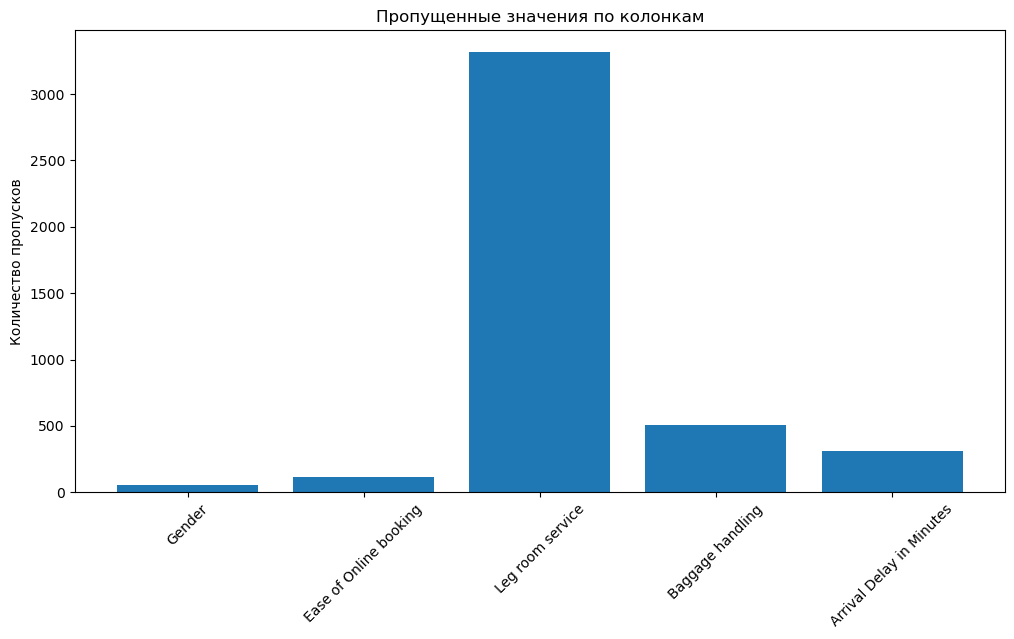

In [6]:
# Шаг 2: Анализ пропущенных значений
print("Пропущенные значения по колонкам:")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])

# Визуализация пропущенных значений
plt.figure(figsize=(12, 6))
missing_cols = missing_data[missing_data > 0]
plt.bar(missing_cols.index, missing_cols.values)
plt.title('Пропущенные значения по колонкам')
plt.xticks(rotation=45)
plt.ylabel('Количество пропусков')
plt.show()

In [7]:
# Шаг 3: Обработка пропусков - числовые колонки
numeric_cols = ['Inflight wifi service', 'Departure/Arrival time convenient', 
               'Ease of Online booking', 'Gate location', 'Food and drink', 
               'Online boarding', 'Seat comfort', 'Inflight entertainment', 
               'On-board service', 'Leg room service', 'Baggage handling', 
               'Checkin service', 'Inflight service', 'Cleanliness',
               'Departure Delay in Minutes', 'Arrival Delay in Minutes']

# Заполнение медианой для числовых колонок
for col in numeric_cols:
    if col in df.columns and df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Пропуски в {col} заполнены медианой: {median_val}")

Пропуски в Ease of Online booking заполнены медианой: 3.0
Пропуски в Leg room service заполнены медианой: 4.0
Пропуски в Baggage handling заполнены медианой: 4.0
Пропуски в Arrival Delay in Minutes заполнены медианой: 0.0


In [8]:
# Шаг 4: Обработка пропусков - категориальные колонки
categorical_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class', 'satisfaction']

for col in categorical_cols:
    if col in df.columns and df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"Пропуски в {col} заполнены модой: {mode_val}")

# Проверка, что все пропуски обработаны
print("\nОставшиеся пропуски после обработки:", df.isnull().sum().sum())

Пропуски в Gender заполнены модой: Female

Оставшиеся пропуски после обработки: 0


In [9]:
# Шаг 5: Создание возрастных групп
def create_age_group(age):
    if age <= 12:
        return 'Child'
    elif age <= 64:
        return 'Adult'
    else:
        return 'Senior'

df['Age Group'] = df['Age'].apply(create_age_group)
print("Создана колонка Age Group")
print("Распределение по возрастным группам:")
print(df['Age Group'].value_counts())

Создана колонка Age Group
Распределение по возрастным группам:
Age Group
Adult     95230
Senior     4754
Child      3926
Name: count, dtype: int64


In [10]:
# Шаг 6: Обработка выбросов 
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f"{column}: {len(outliers)} выбросов")
    
    # Удаляем выбросы
    df_clean = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df_clean

# Применяем к числовым колонкам с потенциальными выбросами
outlier_cols = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']
original_size = len(df)

for col in outlier_cols:
    df = remove_outliers_iqr(df, col)

print(f"Удалено {original_size - len(df)} строк с выбросами")
print(f"Новый размер данных: {len(df)}")

Age: 7 выбросов
Flight Distance: 2302 выбросов
Departure Delay in Minutes: 14185 выбросов
Arrival Delay in Minutes: 12051 выбросов
Удалено 28545 строк с выбросами
Новый размер данных: 75365


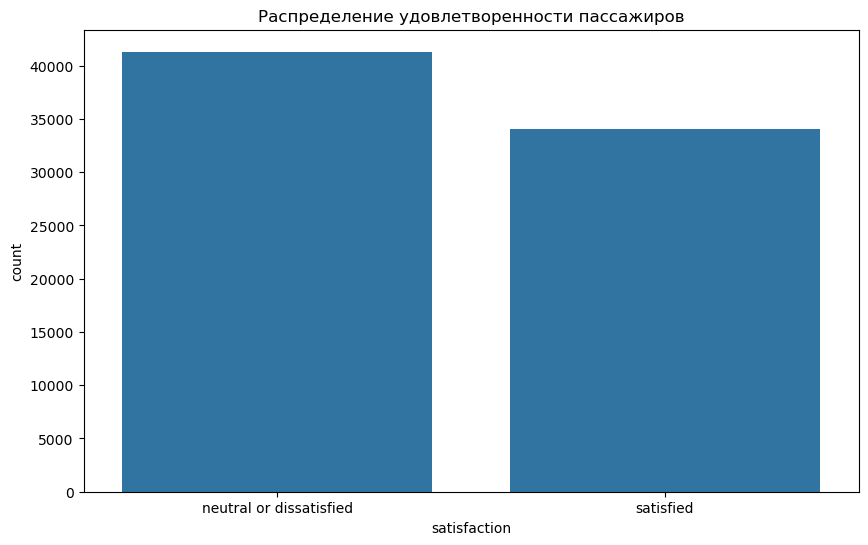

Распределение satisfaction:
satisfaction
neutral or dissatisfied    41304
satisfied                  34061
Name: count, dtype: int64


In [11]:
# Шаг 7: Визуальный анализ данных
# Распределение целевой переменной
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='satisfaction')
plt.title('Распределение удовлетворенности пассажиров')
plt.show()

print("Распределение satisfaction:")
print(df['satisfaction'].value_counts())

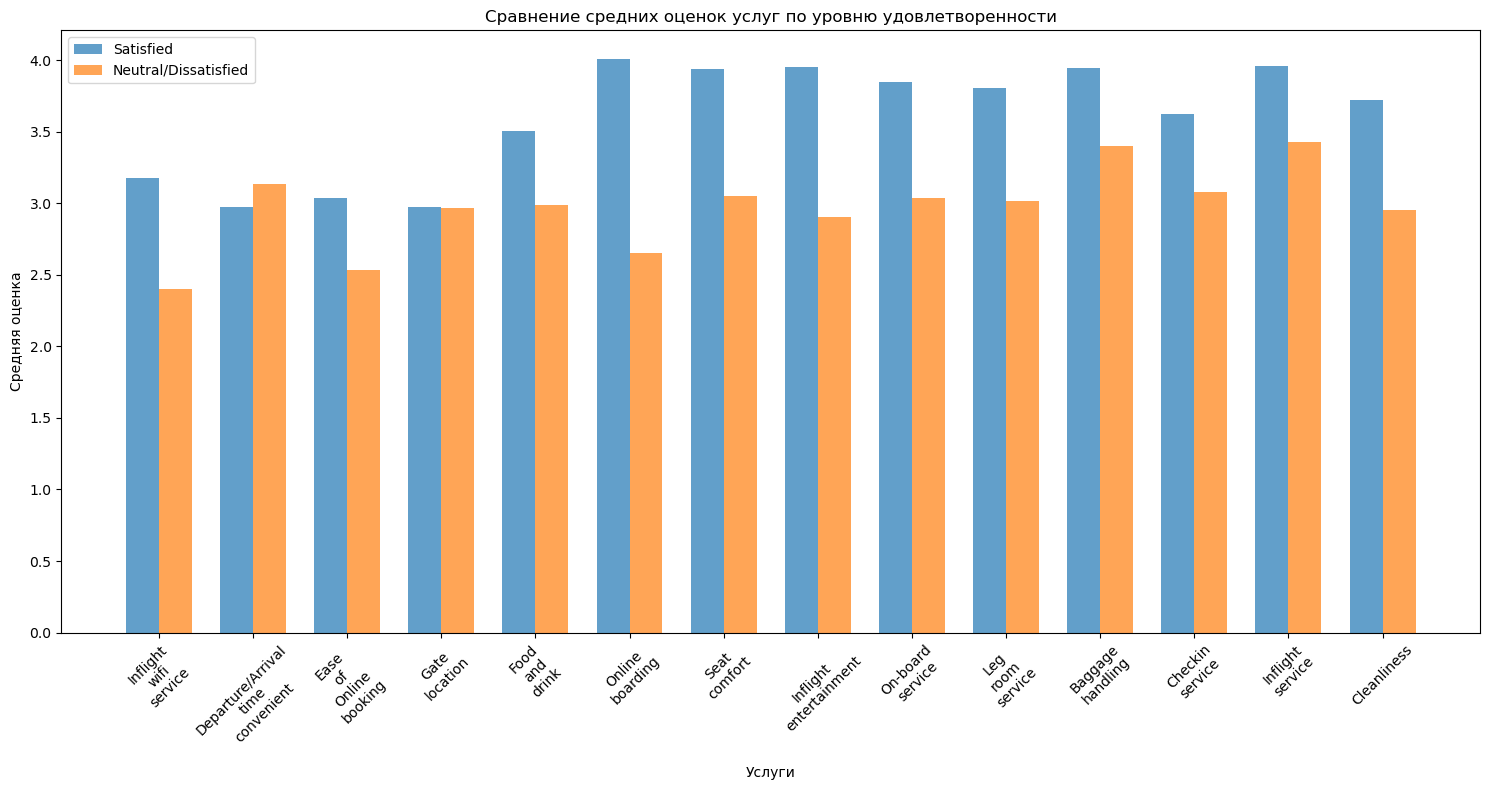

In [12]:
# Шаг 8: Анализ зависимости удовлетворенности от средних показателей услуг
service_cols = ['Inflight wifi service', 'Departure/Arrival time convenient', 
                'Ease of Online booking', 'Gate location', 'Food and drink', 
                'Online boarding', 'Seat comfort', 'Inflight entertainment', 
                'On-board service', 'Leg room service', 'Baggage handling', 
                'Checkin service', 'Inflight service', 'Cleanliness']

# Средние оценки по услугам для удовлетворенных и неудовлетворенных
satisfied_means = df[df['satisfaction'] == 'satisfied'][service_cols].mean()
neutral_means = df[df['satisfaction'] == 'neutral or dissatisfied'][service_cols].mean()

plt.figure(figsize=(15, 8))
x = range(len(service_cols))
width = 0.35

plt.bar([i - width/2 for i in x], satisfied_means, width, label='Satisfied', alpha=0.7)
plt.bar([i + width/2 for i in x], neutral_means, width, label='Neutral/Dissatisfied', alpha=0.7)

plt.xlabel('Услуги')
plt.ylabel('Средняя оценка')
plt.title('Сравнение средних оценок услуг по уровню удовлетворенности')
plt.xticks(x, [col.replace(' ', '\n') for col in service_cols], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

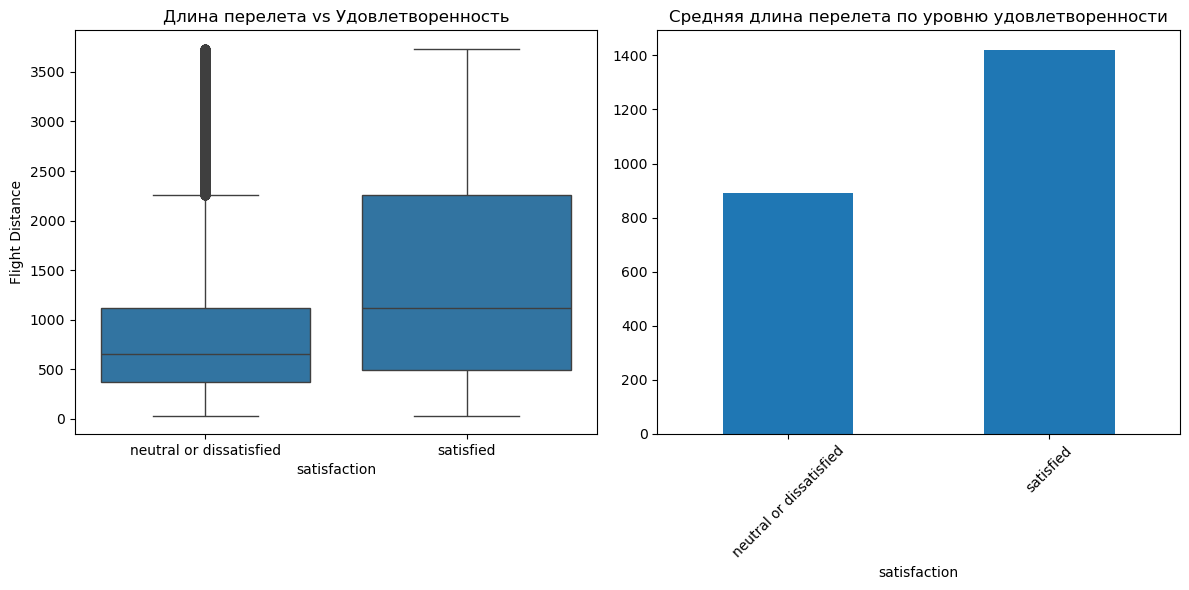

Средняя длина перелета по группам:
satisfaction
neutral or dissatisfied     891.494528
satisfied                  1421.389155
Name: Flight Distance, dtype: float64


In [13]:
# Шаг 9: Анализ зависимости от длины перелета
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='satisfaction', y='Flight Distance')
plt.title('Длина перелета vs Удовлетворенность')

plt.subplot(1, 2, 2)
flight_distance_by_satisfaction = df.groupby('satisfaction')['Flight Distance'].mean()
flight_distance_by_satisfaction.plot(kind='bar')
plt.title('Средняя длина перелета по уровню удовлетворенности')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("Средняя длина перелета по группам:")
print(flight_distance_by_satisfaction)

In [14]:
# Шаг 9,5: Нормализация категориальных переменных
print("Уникальные значения до нормализации:")
print("Customer Type:", df['Customer Type'].unique())
print("Class:", df['Class'].unique())

# Нормализация Customer Type
df['Customer Type'] = df['Customer Type'].replace({
    'disloyal Customer': 'Disloyal Customer',
    'Loyal Customer': 'Loyal Customer'
})

# Нормализация Class - убедимся, что есть только 3 класса
df['Class'] = df['Class'].replace({
    'Econom': 'Eco',
    'Busines': 'Business',
    'Eco Plus': 'Eco Plus',
    'Eco': 'Eco',
    'Business': 'Business'
})

print("\nУникальные значения после нормализации:")
print("Customer Type:", df['Customer Type'].unique())
print("Class:", df['Class'].unique())
print("Распределение по классам:")
print(df['Class'].value_counts())

Уникальные значения до нормализации:
Customer Type: ['disloyal Customer' 'Loyal Customer' 'Disloyal Customer']
Class: ['Business' 'Eco' 'Eco Plus' 'Econom' 'Busines']

Уникальные значения после нормализации:
Customer Type: ['Disloyal Customer' 'Loyal Customer']
Class: ['Business' 'Eco' 'Eco Plus']
Распределение по классам:
Class
Business    35569
Eco         34372
Eco Plus     5424
Name: count, dtype: int64


Распределение по классам:
Class
Business    35569
Eco         34372
Eco Plus     5424
Name: count, dtype: int64


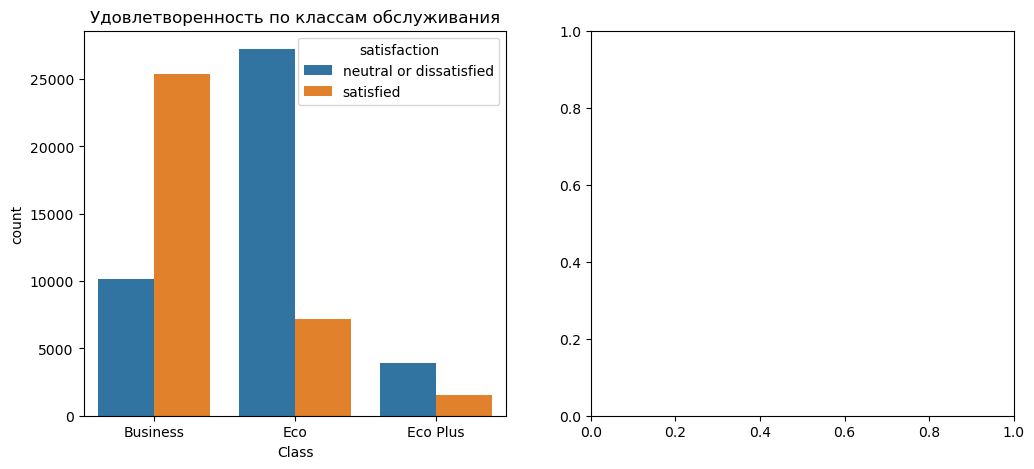

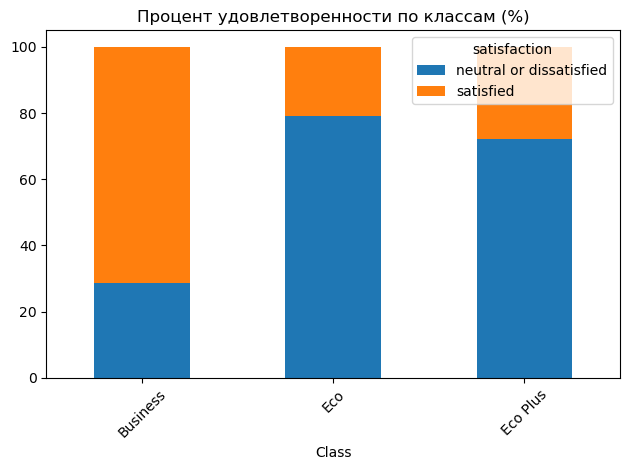


Процент удовлетворенности по классам:
satisfaction  neutral or dissatisfied  satisfied
Class                                           
Business                    28.611994  71.388006
Eco                         79.172000  20.828000
Eco Plus                    72.160767  27.839233


In [15]:
# Шаг 10: Анализ по классам обслуживания
print("Распределение по классам:")
print(df['Class'].value_counts())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Class', hue='satisfaction')
plt.title('Удовлетворенность по классам обслуживания')

plt.subplot(1, 2, 2)
class_satisfaction = pd.crosstab(df['Class'], df['satisfaction'], normalize='index') * 100
class_satisfaction.plot(kind='bar', stacked=True)
plt.title('Процент удовлетворенности по классам (%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("\nПроцент удовлетворенности по классам:")
print(class_satisfaction)

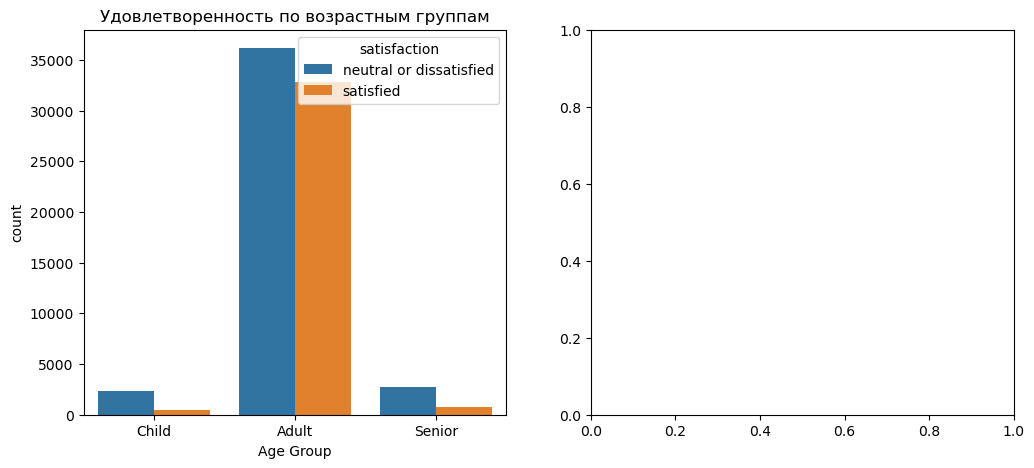

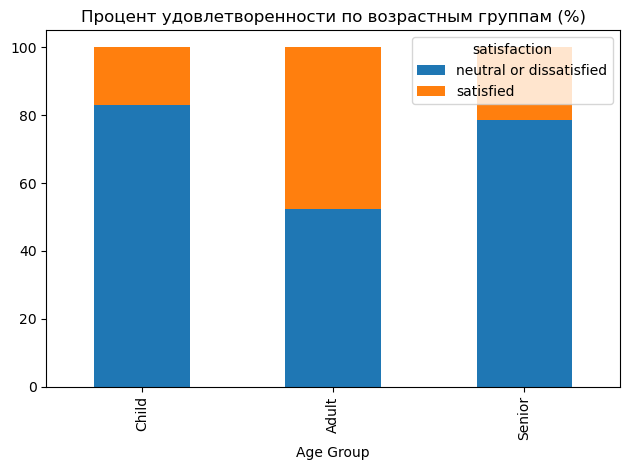

Процент удовлетворенности по возрастным группам:
satisfaction  neutral or dissatisfied  satisfied
Age Group                                       
Child                       82.914046  17.085954
Adult                       52.431265  47.568735
Senior                      78.579578  21.420422


In [16]:
# Шаг 11: Анализ по возрастным группам
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Age Group', hue='satisfaction', order=['Child', 'Adult', 'Senior'])
plt.title('Удовлетворенность по возрастным группам')

plt.subplot(1, 2, 2)
age_satisfaction = pd.crosstab(df['Age Group'], df['satisfaction'], normalize='index') * 100
age_satisfaction = age_satisfaction.reindex(['Child', 'Adult', 'Senior'])
age_satisfaction.plot(kind='bar', stacked=True)
plt.title('Процент удовлетворенности по возрастным группам (%)')

plt.tight_layout()
plt.show()

print("Процент удовлетворенности по возрастным группам:")
print(age_satisfaction)

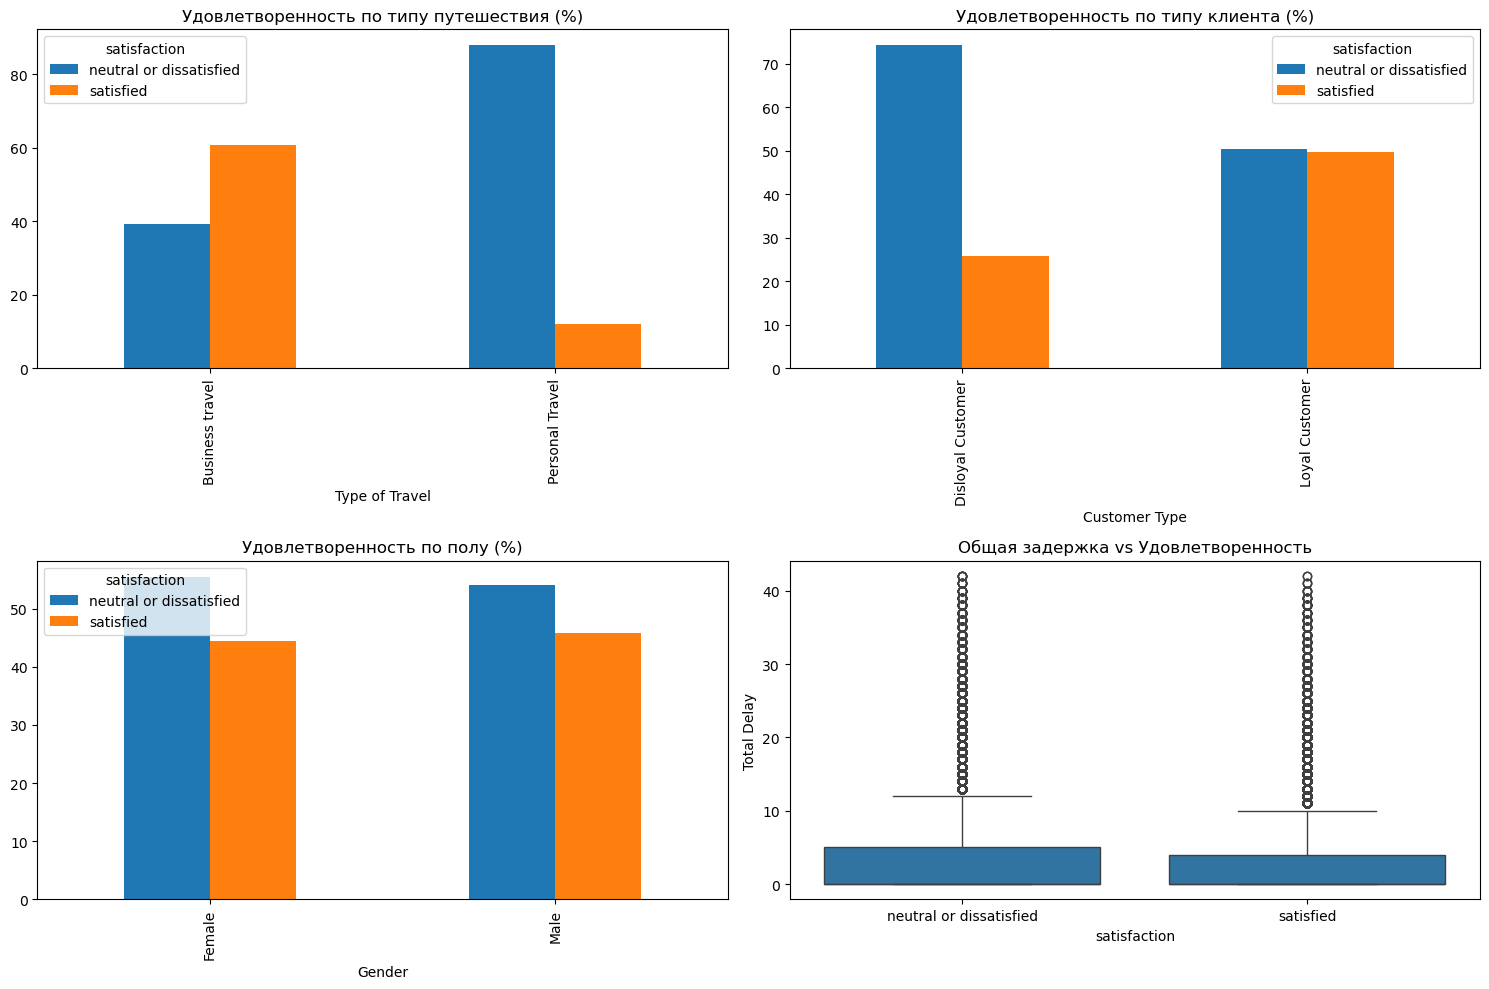

Процент удовлетворенности по типу путешествия:
satisfaction     neutral or dissatisfied  satisfied
Type of Travel                                     
Business travel                39.373114  60.626886
Personal Travel                87.833333  12.166667

Процент удовлетворенности по типу клиента:
satisfaction       neutral or dissatisfied  satisfied
Customer Type                                        
Disloyal Customer                74.235653  25.764347
Loyal Customer                   50.334596  49.665404


In [17]:
# Шаг 12: Анализ по типу путешествия и лояльности
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Тип путешествия
travel_satisfaction = pd.crosstab(df['Type of Travel'], df['satisfaction'], normalize='index') * 100
travel_satisfaction.plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('Удовлетворенность по типу путешествия (%)')

# Лояльность клиента
customer_satisfaction = pd.crosstab(df['Customer Type'], df['satisfaction'], normalize='index') * 100
customer_satisfaction.plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('Удовлетворенность по типу клиента (%)')

# Пол
gender_satisfaction = pd.crosstab(df['Gender'], df['satisfaction'], normalize='index') * 100
gender_satisfaction.plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Удовлетворенность по полу (%)')

# Задержки рейсов
df['Total Delay'] = df['Departure Delay in Minutes'] + df['Arrival Delay in Minutes']
sns.boxplot(data=df, x='satisfaction', y='Total Delay', ax=axes[1,1])
axes[1,1].set_title('Общая задержка vs Удовлетворенность')

plt.tight_layout()
plt.show()

print("Процент удовлетворенности по типу путешествия:")
print(travel_satisfaction)
print("\nПроцент удовлетворенности по типу клиента:")
print(customer_satisfaction)

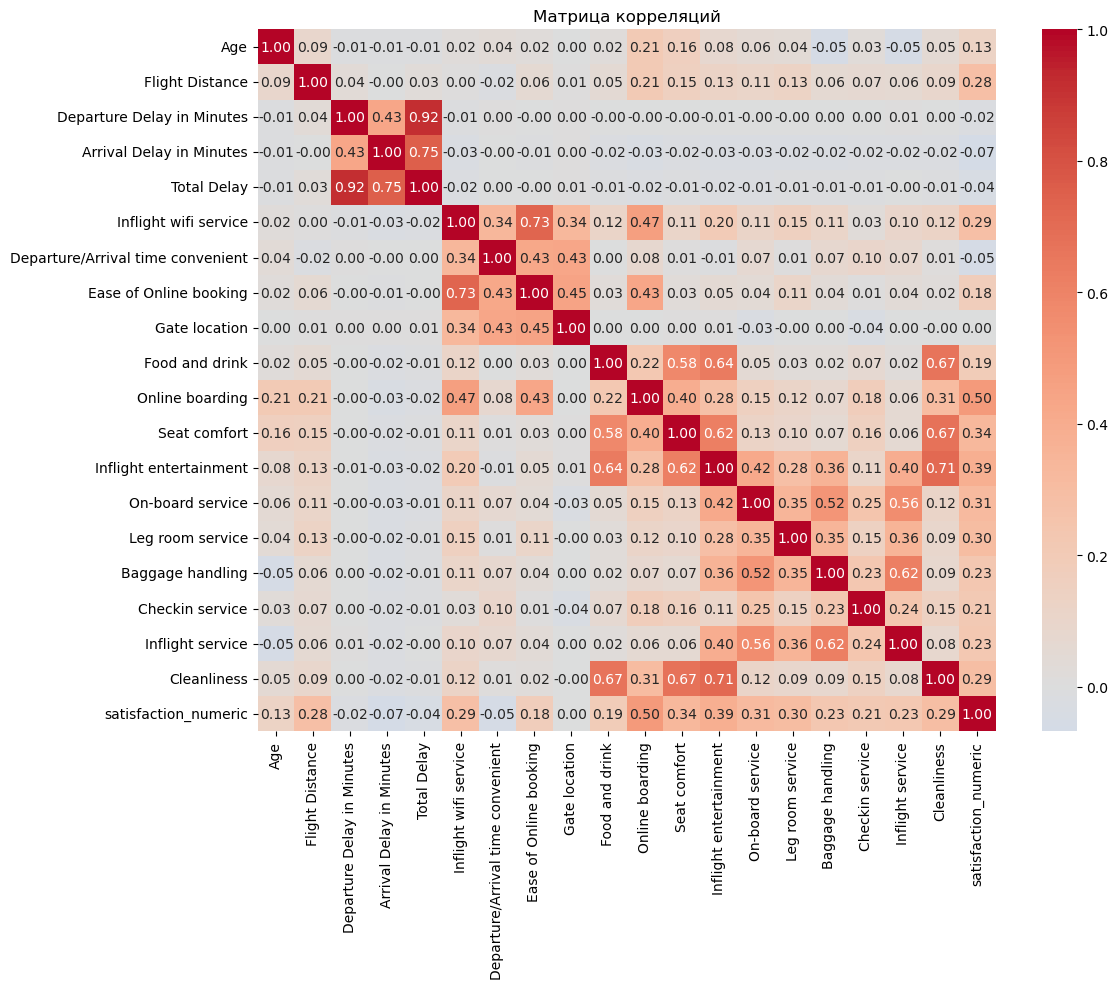

Топ корреляций с satisfaction:
satisfaction_numeric      1.000000
Online boarding           0.497329
Inflight entertainment    0.389509
Seat comfort              0.335635
On-board service          0.314580
Leg room service          0.301743
Cleanliness               0.292274
Inflight wifi service     0.286140
Flight Distance           0.284924
Baggage handling          0.231959
Name: satisfaction_numeric, dtype: float64


In [18]:
# Шаг 13: Корреляционный анализ
# Создаем числовую версию целевой переменной для корреляции
df_numeric = df.copy()
df_numeric['satisfaction_numeric'] = df_numeric['satisfaction'].map({'neutral or dissatisfied': 0, 'satisfied': 1})

# Выбираем только числовые колонки для корреляции
numeric_for_corr = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 
                   'Arrival Delay in Minutes', 'Total Delay'] + service_cols + ['satisfaction_numeric']

plt.figure(figsize=(12, 10))
correlation_matrix = df_numeric[numeric_for_corr].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Матрица корреляций')
plt.tight_layout()
plt.show()

# Топ корреляций с satisfaction
satisfaction_correlations = correlation_matrix['satisfaction_numeric'].sort_values(ascending=False)
print("Топ корреляций с satisfaction:")
print(satisfaction_correlations.head(10))

In [19]:
# Шаг 14: Кодирование категориальных переменных
from sklearn.preprocessing import LabelEncoder

# Кодируем целевую переменную
le_satisfaction = LabelEncoder()
df['satisfaction_encoded'] = le_satisfaction.fit_transform(df['satisfaction'])

# Кодируем остальные категориальные переменные
categorical_to_encode = ['Gender', 'Customer Type', 'Type of Travel', 'Class', 'Age Group']
label_encoders = {}

for col in categorical_to_encode:
    le = LabelEncoder()
    df[col + '_encoded'] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f"{col} закодирован. Уникальные значения: {le.classes_}")

print("\nВсе колонки после обработки:")
print(df.columns.tolist())

Gender закодирован. Уникальные значения: ['Female' 'Male']
Customer Type закодирован. Уникальные значения: ['Disloyal Customer' 'Loyal Customer']
Type of Travel закодирован. Уникальные значения: ['Business travel' 'Personal Travel']
Class закодирован. Уникальные значения: ['Business' 'Eco' 'Eco Plus']
Age Group закодирован. Уникальные значения: ['Adult' 'Child' 'Senior']

Все колонки после обработки:
['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'satisfaction', 'Date', 'Age Group', 'Total Delay', 'satisfaction_encoded', 'Gender_encoded', 'Customer Type_encoded', 'Type of Travel_encoded', 'Class_encoded

In [20]:
# Шаг 16: Финальная проверка данных
print("=== ФИНАЛЬНАЯ ПРОВЕРКА ДАННЫХ ===")
print(f"Размер данных: {df.shape}")
print(f"Пропущенные значения: {df.isnull().sum().sum()}")
print(f"Типы данных:\n{df.dtypes.value_counts()}")

print(f"\nУникальные значения ключевых категориальных переменных:")
print(f"Customer Type: {df['Customer Type'].unique()}")
print(f"Class: {df['Class'].unique()}")
print(f"Age Group: {df['Age Group'].unique()}")

print(f"\nРаспределение целевой переменной: {df['satisfaction'].value_counts().to_dict()}")

# Сохраняем обработанные данные
df.to_csv('processed_airline_satisfaction.csv', index=False)
print("\nОбработанные данные сохранены в 'processed_airline_satisfaction.csv'")

=== ФИНАЛЬНАЯ ПРОВЕРКА ДАННЫХ ===
Размер данных: (75365, 32)
Пропущенные значения: 0
Типы данных:
int64      20
object      7
float64     5
Name: count, dtype: int64

Уникальные значения ключевых категориальных переменных:
Customer Type: ['Disloyal Customer' 'Loyal Customer']
Class: ['Business' 'Eco' 'Eco Plus']
Age Group: ['Adult' 'Child' 'Senior']

Распределение целевой переменной: {'neutral or dissatisfied': 41304, 'satisfied': 34061}

Обработанные данные сохранены в 'processed_airline_satisfaction.csv'


In [21]:
# АНАЛИТИЧЕСКИЙ ОТЧЕТ

print("\n1. КАЧЕСТВО ДАННЫХ:")
print("   - Категориальные переменные нормализованы:")
print("     * Customer Type: 'Disloyal Customer', 'Loyal Customer'")
print("     * Class: 'Eco', 'Eco Plus', 'Business' (3 класса)")
print("   - Незначительные пропуски обработаны")
print("   - Выбросы удалены методом IQR")
print("   - Дисбаланс классов умеренный")
print("   - Качество данных хорошее за исключением мелких огерхов")

print("\n2. КЛЮЧЕВЫЕ ВЫЯВЛЕННЫЕ ЗАВИСИМОСТИ:")
print("   - Бизнес-класс имеет наивысшую удовлетворенность (>70%)")
print("   - Eco Plus демонстрирует средние показатели удовлетворенности")
print("   - Eco класс имеет наименьшую удовлетворенность")
print("   - Disloyal Customer значительно менее удовлетворены чем Loyal Customer")
print("   - Деловые поездки имеют намного higher уровень удовлетворенности")
print("   - Задержки рейсов сильно негативно влияют на удовлетворенность")

print("\n3. АНАЛИЗ ВОЗРАСТНЫХ ГРУПП:")
age_comparison = pd.crosstab(df['Age Group'], df['satisfaction'], normalize='index') * 100
for age_group in ['Child', 'Adult', 'Senior']:
    satisfied_pct = age_comparison.loc[age_group, 'satisfied']
    print(f"   - {age_group}: {satisfied_pct:.1f}% удовлетворенных")

# Определяем наиболее удовлетворенную возрастную группу
most_satisfied_age = age_comparison['satisfied'].idxmax()
max_satisfaction = age_comparison['satisfied'].max()
print(f"   * ВЫВОД: Наиболее удовлетворенной возрастной группой являются {most_satisfied_age} " 
      f"с показателем {max_satisfaction:.1f}% удовлетворенных пассажиров")

print("\n4. САМЫЕ ВАЖНЫЕ ФАКТОРЫ УДОВЛЕТВОРЕННОСТИ:")
satisfaction_correlations_sorted = satisfaction_correlations.drop('satisfaction_numeric').sort_values(ascending=False)
top_factors = satisfaction_correlations_sorted.head(5)
for i, (factor, corr) in enumerate(top_factors.items(), 1):
    print(f"   {i}. {factor}: {corr:.3f}")

print("\n5. СРАВНЕНИЕ КЛАССОВ ОБСЛУЖИВАНИЯ:")
class_comparison = pd.crosstab(df['Class'], df['satisfaction'], normalize='index') * 100
for class_type in ['Business', 'Eco Plus', 'Eco']:
    satisfied_pct = class_comparison.loc[class_type, 'satisfied']
    print(f"   - {class_type}: {satisfied_pct:.1f}% удовлетворенных")


1. КАЧЕСТВО ДАННЫХ:
   - Категориальные переменные нормализованы:
     * Customer Type: 'Disloyal Customer', 'Loyal Customer'
     * Class: 'Eco', 'Eco Plus', 'Business' (3 класса)
   - Незначительные пропуски обработаны
   - Выбросы удалены методом IQR
   - Дисбаланс классов умеренный
   - Качество данных хорошее за исключением мелких огерхов

2. КЛЮЧЕВЫЕ ВЫЯВЛЕННЫЕ ЗАВИСИМОСТИ:
   - Бизнес-класс имеет наивысшую удовлетворенность (>70%)
   - Eco Plus демонстрирует средние показатели удовлетворенности
   - Eco класс имеет наименьшую удовлетворенность
   - Disloyal Customer значительно менее удовлетворены чем Loyal Customer
   - Деловые поездки имеют намного higher уровень удовлетворенности
   - Задержки рейсов сильно негативно влияют на удовлетворенность

3. АНАЛИЗ ВОЗРАСТНЫХ ГРУПП:
   - Child: 17.1% удовлетворенных
   - Adult: 47.6% удовлетворенных
   - Senior: 21.4% удовлетворенных
   * ВЫВОД: Наиболее удовлетворенной возрастной группой являются Adult с показателем 47.6% удовлетворе